- Simple Up/Downconversion
- Downsampling (aliasing)
- FIR downsampling?

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
plt.rcParams.update({
    # Figure & Resolution
    'figure.figsize': (3, 1.5),      # Standard rectangular size
    'figure.dpi': 100,             # High resolution for saving
    'savefig.dpi': 300,            # High resolution for exported images
    'savefig.bbox': 'tight',       # Removes unnecessary white space around the plot
    
    # Fonts & Text
    'font.family': 'sans-serif',   # Use serif for traditional journals, sans-serif for modern
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,               # Base font size
    'axes.titlesize': 10,          # Title size
    'axes.labelsize': 10,          # X and Y label size
    'xtick.labelsize': 10,         # Tick label size
    'ytick.labelsize': 10,         # Tick label size
    'legend.fontsize': 10,         # Legend text size
    
    # Axes & Spines (The "Clean" Look)
    'axes.spines.top': False,      # Remove top bounding box line
    'axes.spines.right': False,    # Remove right bounding box line
    'axes.linewidth': 1.1,         # Slightly thicker axes lines
    'axes.grid': False,            # Default to no grid (turn on manually if needed)
    
    # Ticks
    'xtick.direction': 'in',       # Ticks point inward
    'ytick.direction': 'in',       # Ticks point inward
    'xtick.major.size': 6,         # Major tick length
    'xtick.major.width': 1.2,      # Major tick thickness
    'ytick.major.size': 6,         # Major tick length
    'ytick.major.width': 1.2,      # Major tick thickness
    
    # Lines & Markers
    'lines.linewidth': 1.5,        # Thicker lines for visibility
    'lines.markersize': 4,         # Standard marker size
    
    # Legend
    'legend.frameon': False,       # Remove the box around the legend
    'legend.loc': 'best'           # Automatically place legend out of the way
})

Let us continue our analysis of narrow-band signals. In part 1, we used aliasing to our benefit to retain all the spectral information while sampling at a much lower rate. Real-life differs in two important aspects.

1. We cheated in part 1 by having the center frequency at the exact center of 256-long DFT, and we made it an exact multiple of the downsampling rate. This resulted in our signal aliasing nicely to 0. In reality, the center frequency of, say, an FM signal we want to pick up may not be at the center of whatever DFT our hardware allows. We may not even have digital hardware to do DFTs and might want to do all our signal processing with analog devices.
2. We assumed that everything outside of our signal bandwidth was 0. In reality there's all kinds of stuff an antenna picks up. We need to extract only the part we care about.

x type: float64 x2 type: complex128


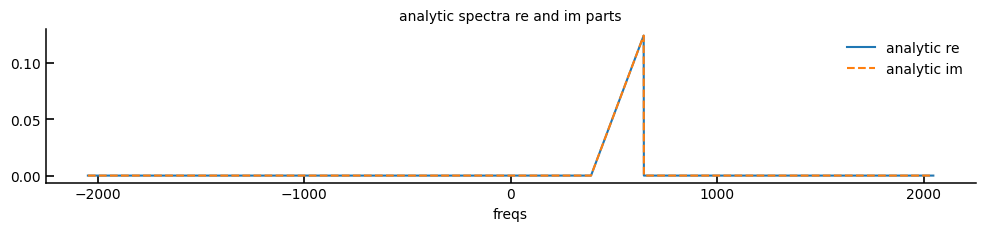

In [33]:
#generate some spectra

Norig = 256
extend = 16
N = Norig * extend
X = np.zeros(N//2+1,dtype='complex128')
Xc = np.zeros(N,dtype='complex128') #analytic
k0 = 32 * extend + 5 #Will not be at the center of any channel of smaller FFT sizes. 
dk = 8 * extend
triangle = np.arange(0,2*dk)/N + 1j*np.arange(0,2*dk)/N #triangular real and imag parts (not-symmetric)

X[k0-dk:k0+dk]=triangle 
x=np.fft.irfft(X) #note irfft. -ve freqs will be conjugate of +ve freqs.  generates a real signal


Xc[k0-dk:k0+dk]=2*triangle # ignore -ve freqs and double +ve freqs
x2=np.fft.ifft(Xc) #note ifft.  generates a complex signal

freqs = np.fft.fftshift(np.fft.fftfreq(N))*N
# print(freqs)
fig=plt.gcf()
fig.set_size_inches(12,2)
plt.plot(freqs,np.fft.fftshift(np.fft.fft(x2).real),label='analytic re' )
plt.plot(freqs,np.fft.fftshift(np.fft.fft(x2).imag),label='analytic im' ,ls='dashed')
plt.xlabel("freqs")
plt.title("analytic spectra re and im parts")
plt.legend()


print("x type:", x.dtype, "x2 type:", x2.dtype)

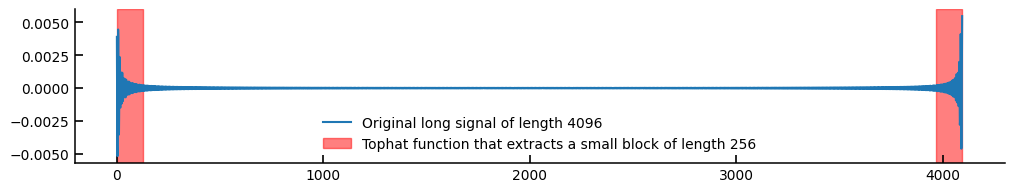

In [5]:
fig=plt.gcf()
fig.set_size_inches(12,2)
plt.plot(x2.real,label=f'Original long signal of length {N}')
plt.axvspan(0,Norig//2,color='red',alpha=0.5, label=f'Tophat function that extracts a small block of length {Norig}')
plt.axvspan(N-Norig//2,N,color='red',alpha=0.5)
plt.legend()

Let's look at the FFT of original length (256) for a block of data. Note that we'll have to extract negative times (past) as well , in order to avoid hard truncaation.

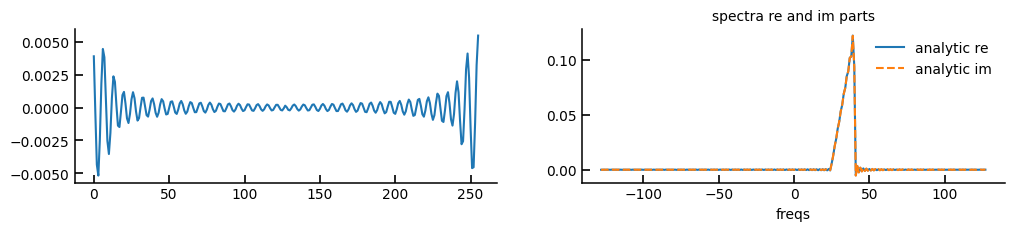

In [6]:
#small x
x2_small = np.zeros(256, dtype=x2.dtype)
x2_small[:128]=x2[:128]
x2_small[-128:]=x2[-128:]
freqs_small = np.fft.fftshift(np.fft.fftfreq(256))*256
fig=plt.gcf()
fig.set_size_inches(12,2)
plt.subplot(121)
plt.plot(x2_small.real)
plt.subplot(122)
plt.plot(freqs_small,np.fft.fftshift(np.fft.fft(x2_small).real),label='analytic re' )
plt.plot(freqs_small,np.fft.fftshift(np.fft.fft(x2_small).imag),label='analytic im' ,ls='dashed')
plt.xlabel("freqs")
plt.title("spectra re and im parts")
plt.legend()

With smaller FFT size, the signal's center freq is now at channel number 32 + 5/16, which is not an integer. The spectrum will now be distorted.

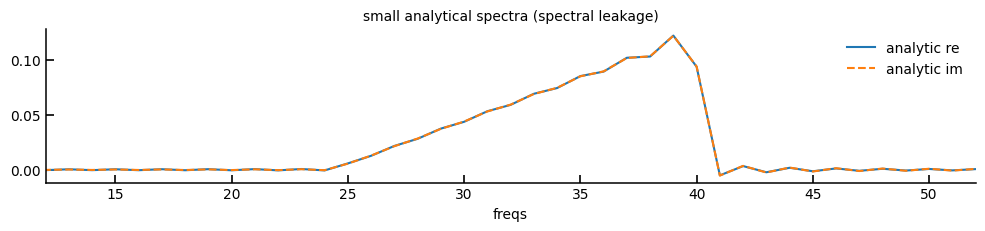

In [7]:
fig=plt.gcf()
fig.set_size_inches(12,2)

plt.plot(freqs_small,np.fft.fftshift(np.fft.fft(x2_small).real),label='analytic re' )
plt.plot(freqs_small,np.fft.fftshift(np.fft.fft(x2_small).imag),label='analytic im' ,ls='dashed')
plt.xlabel("freqs")
plt.title("small analytical spectra (spectral leakage)")
plt.xlim(k0//extend-20, k0//extend+20)
plt.legend()

By taking a shorter FFT we've first multiplied the long timestream with a tophat function. This results in the "original" near-continuous spectrum to get convolved with a sinc --- we've lost information on scales smaller than 1/256 samples.

But..we can still extract a triangle by "downconverting" in time-domain.

I can move the triangle down to zero (shift left) by convolving the spectra with a delta function centered at the -ve of carrier frequency. As convolution in one domain is a multiplication with the fourier transform in the corresponding domain, let's see what this operation does to the spectra.

$ Y[k] =  \sum_k' X[k - k'] \delta [k'+k_0]$

(-128.0, 129.0)

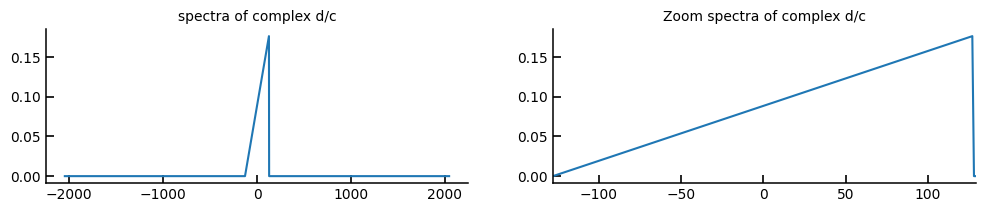

In [11]:
x2_rotated = x2*np.exp(-2j*np.pi*np.arange(N)*k0/N)
fig=plt.gcf()
fig.set_size_inches(12,2)
plt.subplot(121)
plt.title("spectra of complex d/c")
plt.plot(freqs,np.fft.fftshift(np.abs(np.fft.fft(x2_rotated))))
plt.subplot(122)
plt.title("Zoom spectra of complex d/c")
plt.plot(freqs,np.fft.fftshift(np.abs(np.fft.fft(x2_rotated))))
plt.xlim(0-dk,0+dk+1)

If we wanted to, we can now safely bring the sampling frequency down because there's no information in higher frequencies.

new FFT length 256


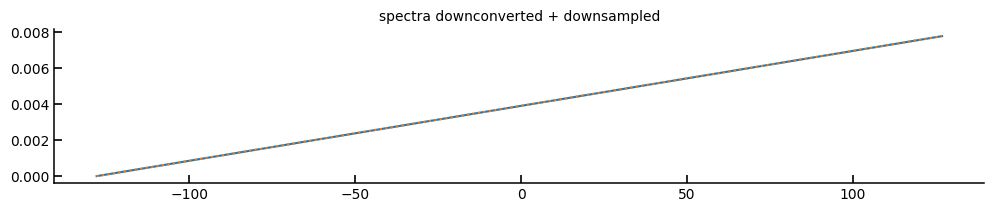

In [19]:
x2_rotated_downsampled = x2_rotated[::extend]
new_freqs = np.fft.fftshift(np.fft.fftfreq(len(x2_rotated_downsampled)))*len(x2_rotated_downsampled)
fig=plt.gcf()
fig.set_size_inches(12,2)
plt.title('spectra downconverted + downsampled')
plt.plot(new_freqs, np.fft.fftshift(np.fft.fft(x2_rotated_downsampled).real),label='real')
plt.plot(new_freqs, np.fft.fftshift(np.fft.fft(x2_rotated_downsampled).imag), ls='dotted',label='imag')
print("new FFT length", len(x2_rotated_downsampled))

Note that spectrum of signal is NOT symmetric around zero, which means that the timestream that gave rise to this spectrum must be complex. This is the downconverted and downsampled timestream we FFT'ed above.

The real and imag part of the timestream are referred to as I (for in-phase) and Q (for quadrature) components respectively.

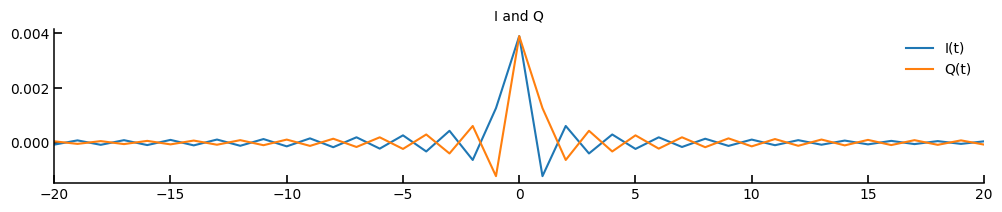

In [24]:
fig=plt.gcf()
fig.set_size_inches(12,2)
plt.title('I and Q')
plt.plot(new_freqs, np.fft.fftshift(x2_rotated_downsampled.real),label='I(t)')
plt.plot(new_freqs, np.fft.fftshift(x2_rotated_downsampled.imag),label='Q(t)')
plt.xlim(-20,20)
plt.legend()

Exercise: downconvert and plot the spectrum of the real signal.

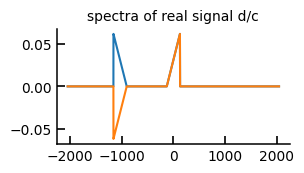

In [25]:
x_rotated = x*np.exp(-2j*np.pi*np.arange(N)*k0/N)
plt.title("spectra of real signal d/c")
plt.plot(freqs,np.fft.fftshift(np.fft.fft(x_rotated).real))
plt.plot(freqs,np.fft.fftshift(np.fft.fft(x_rotated).imag))

We see that convolution with the delta function at $-k_0$ brough the stuff at +ve frequencies down to zero, but also created images at $-2k_0$. To obtain the region of interest around 0, we'll have to get rid of the crap at negative frequencies using a filter. We shall see how to do this filtering in the next notebook.

But, in general, the sequence of steps in real-life to obtain the spectral information we care about without distorting is as follows:

$I(t) = \text{Lowpass Filter}\;[y(t)cos(2 \pi f_0 t)]$

$Q(t) = \text{Lowpass Filter}\;[-y(t)sin(2 \pi f_0 t)]$

To do the opposite: given a spectrum (or equivalently I and Q samples) that we want to broadcast or put on a carrier wave, we can analogously upconvert. We start from a spectrum around 0, and we want to move it to the right. To do this, we convolve with a delta function at the +ve frequency of interest.

$ Y[k] =  \sum_k' X[k - k'] \delta [k'-k_0]$

So that

$y(t) = \mathcal{R}\{ [I(t) + j Q(t)] e^{j2\pi f_0 t} \} = I(t)cos(2 \pi f_0 t) - Q(t)sin(2 \pi f_0 t)$

The upconversion part is simple. Multiply the narrow-band signal that we have downconverted but not yet downsampled (retained the high sampling rate) by a positive complex exponential.

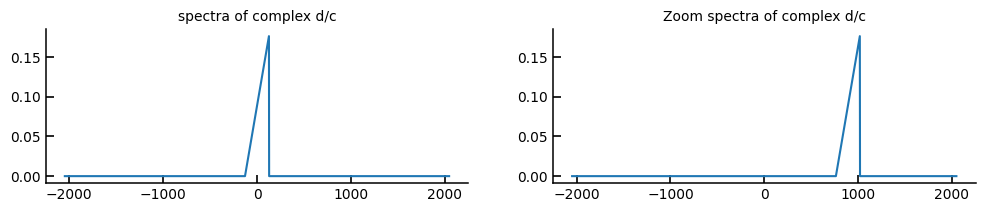

In [38]:
new_k0 = 891
x2_rotated_up = x2_rotated * np.exp(2j*np.pi*np.arange(N)*new_k0/N)
fig=plt.gcf()
fig.set_size_inches(12,2)
plt.subplot(121)
plt.title("spectra of complex d/c")
plt.plot(freqs,np.fft.fftshift(np.abs(np.fft.fft(x2_rotated))))
plt.subplot(122)
plt.title("Zoom spectra of complex d/c")
plt.plot(freqs,np.fft.fftshift(np.abs(np.fft.fft(x2_rotated_up))))


The tricky part is upsampling the low-sample rate I(t) and Q(t). We've achieved upsampling above, in effect, by simply appending zeros to the 256-long triangle spectrum. This works for a single block of test data because the test signal is finite and periodic.

We'll see how up/down conversion and up/down sampling work on a realistic, long timestream that's not periodic next.